In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import sys
from pathlib import Path
import torch
import yaml
from rdkit import Chem
import copy
from tqdm import tqdm

## Checking co-reation between precursor mass difference and cosine similarity

In [ ]:
# ==========================================
# 1. SETUP PATHS
# ==========================================
# Update these paths to point to your actual data files
pairs_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_spec_sim_dataset_train.feather'
spec_meta_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl'
mol_meta_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_spec_sim.pkl'
output_dir = './analysis_plots'

In [ ]:
# 2. LOAD DATA
# ==========================================
print("Loading data...")
df_pairs = pd.read_feather(pairs_path)
df_spec = pd.read_pickle(spec_meta_path)

Loading dataset and metadata files...


In [ ]:
df_mol = pd.read_pickle(mol_meta_path)

In [82]:
df_mol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30101 entries, 0 to 30100
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   smiles      30101 non-null  object 
 1   mol_id      30101 non-null  int64  
 2   mol         30101 non-null  object 
 3   inchikey_s  30101 non-null  object 
 4   scaffold    30101 non-null  object 
 5   formula     30101 non-null  object 
 6   inchi       30101 non-null  object 
 7   mw          30101 non-null  float64
 8   exact_mw    30101 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 2.1+ MB


In [83]:
df_spec.head()

,spec_id,mol_id,prec_type,inst_type,frag_mode,ion_mode,dset,res,ace,nce,prec_mz,peaks,ri
0,MassSpecGymID0036521,22550,[M+H]+,QTOF,CID,P,custom_dataset,4,20.0,NaN,313.148100,"[(213.0501, 0.01461951), (230.0755, 0.02100750...",NaN
1,MassSpecGymID0196017,9073,[M+H]+,Other,CID,P,custom_dataset,6,NaN,NaN,706.401000,"[(75.044678, 0.00057482), (75.062744, 0.000790...",NaN
2,MassSpecGymID0236624,6981,[M+H]+,FT,CID,P,custom_dataset,6,60.0,NaN,625.212700,"[(135.044479, 0.1624), (145.028961, 0.16978000...",NaN
3,MassSpecGymID0081645,83,[M+H]+,QTOF,CID,P,custom_dataset,6,20.0,NaN,223.122975,"[(77.038577, 0.12112112112112113), (94.065126,...",NaN
4,MassSpecGymID0218985,5,[M+H]+,FT,CID,P,custom_dataset,6,20.0,NaN,268.092800,"[(62.018265, 0.00619), (95.023788, 0.002250000...",NaN


In [56]:
# Create lookup for Precursor Mass (spec_id -> prec_mz)
mass_lookup = df_spec.set_index('spec_id')['prec_mz'].to_dict()

In [57]:
mass_lookup

{'MassSpecGymID0036521': 313.1481,
 'MassSpecGymID0196017': 706.401,
 'MassSpecGymID0236624': 625.2127,
 'MassSpecGymID0081645': 223.1229749131,
 'MassSpecGymID0218985': 268.0928,
 'MassSpecGymID0088099': 334.1681,
 'MassSpecGymID0043840': 242.0845,
 'MassSpecGymID0376596': 517.19,
 'MassSpecGymID0268518': 227.18,
 'MassSpecGymID0206203': 321.12699,
 'MassSpecGymID0006106': 347.222,
 'MassSpecGymID0388894': 263.1,
 'MassSpecGymID0004973': 480.309,
 'MassSpecGymID0091296': 217.05,
 'MassSpecGymID0156667': 481.09767,
 'MassSpecGymID0334559': 500.286,
 'MassSpecGymID0183538': 219.113,
 'MassSpecGymID0041035': 300.1473,
 'MassSpecGymID0241330': 360.217,
 'MassSpecGymID0338279': 527.33,
 'MassSpecGymID0013429': 260.165,
 'MassSpecGymID0366145': 597.14,
 'MassSpecGymID0071412': 176.107,
 'MassSpecGymID0194862': 505.13405,
 'MassSpecGymID0101387': 300.1805,
 'MassSpecGymID0238971': 433.2405,
 'MassSpecGymID0274512': 447.129,
 'MassSpecGymID0363340': 521.361,
 'MassSpecGymID0163045': 359.12538

In [58]:
# 3. CALCULATE DIFFERENCES
# ==========================================
print("Calculating mass differences...")

# Extract IDs
ids_a = df_pairs['name_main'].values
ids_b = df_pairs['name_sub'].values

Calculating mass differences...


In [59]:
# Vectorized lookup (much faster than looping)
# We map the IDs to their masses. 
# Note: This assumes all IDs exist in the lookup. If not, use a loop or map with dropna.
mzs_a = np.array([mass_lookup.get(i, np.nan) for i in ids_a])
mzs_b = np.array([mass_lookup.get(i, np.nan) for i in ids_b])

In [60]:
# Calculate Delta m/z and Similarity
mask = ~np.isnan(mzs_a) & ~np.isnan(mzs_b)
mass_diffs = np.abs(mzs_a[mask] - mzs_b[mask])

In [61]:
# Use 'cosine_similarity' if available, otherwise 'label' (0 or 1)
similarities = df_pairs.loc[mask, 'cosine_similarity'].values

In [62]:
# 4. PLOT: The "Forbidden Zone" Analysis
# ==========================================
%matplotlib inline
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

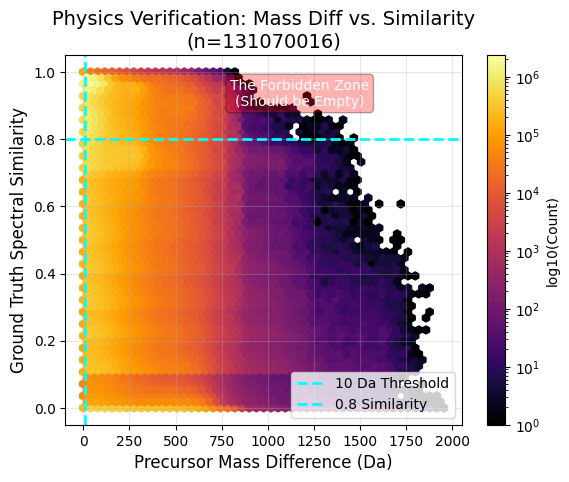

In [63]:
# Use Hexbin for density (Scatter plots get too crowded)
hb = plt.hexbin(
    mass_diffs, 
    similarities, 
    gridsize=50, 
    cmap='inferno', 
    bins='log',  # Log scale highlights rare outliers
    mincnt=1
)

cb = plt.colorbar(hb, label='log10(Count)')

# Draw the "Physics Boundaries"
plt.axvline(x=10, color='cyan', linestyle='--', linewidth=2, label='10 Da Threshold')
plt.axhline(y=0.8, color='cyan', linestyle='--', linewidth=2, label='0.8 Similarity')

# Annotate the "Forbidden Zone"
# (High Mass Diff + High Similarity)
plt.text(
    x=max(mass_diffs) * 0.6, 
    y=0.9, 
    s="The Forbidden Zone\n(Should be Empty)", 
    color='white', 
    ha='center',
    bbox=dict(facecolor='red', alpha=0.3, boxstyle='round')
)

plt.xlabel('Precursor Mass Difference (Da)', fontsize=12)
plt.ylabel('Ground Truth Spectral Similarity', fontsize=12)
plt.title(f'Physics Verification: Mass Diff vs. Similarity\n(n={len(mass_diffs)})', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [64]:
# 5. PRINT STATISTICS
# ==========================================
high_diff = mass_diffs > 10.0
high_sim = similarities > 0.8
violators = np.sum(high_diff & high_sim)
total = len(mass_diffs)

print(f"--- Statistics ---")
print(f"Total Pairs: {total}")
print(f"Violators (Diff > 10Da AND Sim > 0.8): {violators}")
print(f"Violation Rate: {violators/total*100:.4f}%")

if violators/total < 0.01:
    print("\n✅ VERDICT: Physics Assumption Holds. Large mass differences imply low similarity.")
else:
    print("\n⚠️ VERDICT: Assumption Weak. Some molecules have different masses but similar spectra.")

--- Statistics ---
Total Pairs: 131070016
Violators (Diff > 10Da AND Sim > 0.8): 40658527
Violation Rate: 31.0205%

⚠️ VERDICT: Assumption Weak. Some molecules have different masses but similar spectra.


In [65]:
df_eda = pd.DataFrame({'Mass_Diff': mass_diffs, 'Similarity': similarities})

In [69]:
df_eda.head()

,Mass_Diff,Similarity
0,114.075,0.265729
1,234.330,0.729740
2,105.011,0.867486
3,401.433,0.027340
4,292.335,0.212523


In [68]:
# ==========================================
# 3. STATISTICAL ANALYSIS
# ==========================================
# Spearman Correlation (Non-linear)
corr = df_eda.corr(method='spearman').iloc[0, 1]
print(f"\n--- Statistical Signal ---")
print(f"Spearman Correlation (MassDiff vs Similarity): {corr:.4f}")
print("(Close to 0 = Irrelevant. Close to -1 = Strong Negative Relationship)")


--- Statistical Signal ---
Spearman Correlation (MassDiff vs Similarity): -0.2306
(Close to 0 = Irrelevant. Close to -1 = Strong Negative Relationship)


In [70]:
# ==========================================
# 4. BINNING ANALYSIS (The "Box Plot")
# ==========================================
# We bin the mass differences into chemically meaningful categories
bins = [-0.1, 1.0, 10.0, 50.0, 100.0, 2000.0]
labels = ['Isobaric (<1 Da)', 'Tiny (1-10 Da)', 'Medium (10-50 Da)', 'Large (50-100 Da)', 'Huge (>100 Da)']
df_eda['Diff_Category'] = pd.cut(df_eda['Mass_Diff'], bins=bins, labels=labels)

print("\n--- Average Similarity by Category ---")
print(df_eda.groupby('Diff_Category')['Similarity'].mean())


--- Average Similarity by Category ---
Diff_Category
Isobaric (<1 Da)     0.773823
Tiny (1-10 Da)       0.670888
Medium (10-50 Da)    0.661764
Large (50-100 Da)    0.638548
Huge (>100 Da)       0.543953
Name: Similarity, dtype: float64


/tmp/ipykernel_3862080/2247035028.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Diff_Category', y='Similarity', palette='viridis')


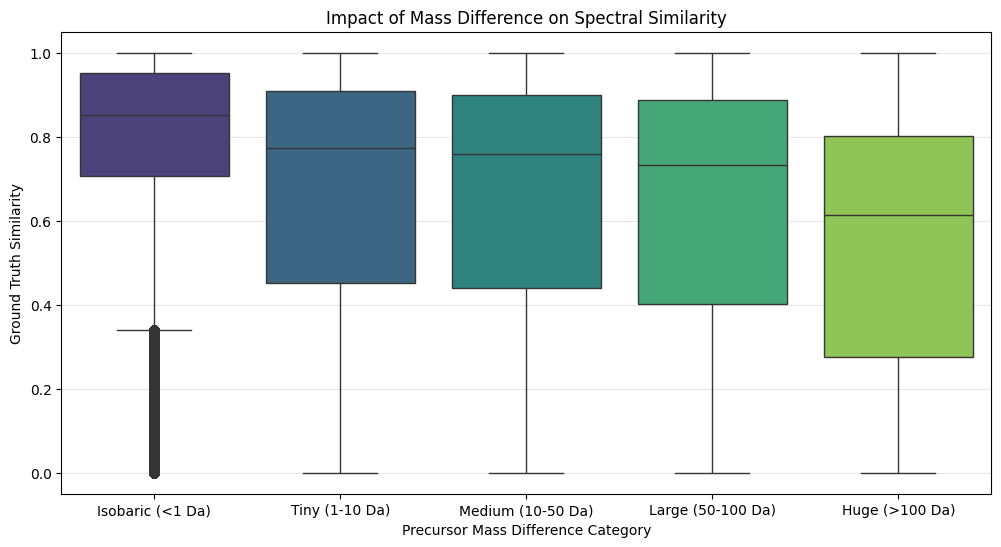

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda, x='Diff_Category', y='Similarity', palette='viridis')
plt.title('Impact of Mass Difference on Spectral Similarity')
plt.ylabel('Ground Truth Similarity')
plt.xlabel('Precursor Mass Difference Category')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

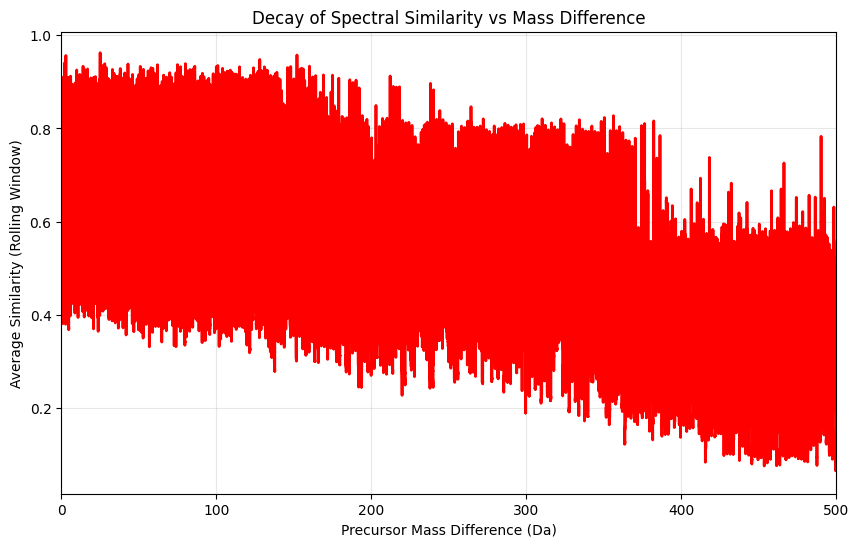

In [73]:
# ==========================================
# 5. ROLLING AVERAGE PLOT
# ==========================================
# This visualizes the "decay" of similarity as mass difference increases
df_sorted = df_eda.sort_values('Mass_Diff')
df_sorted['Rolling_Sim'] = df_sorted['Similarity'].rolling(window=5000).mean()

plt.figure(figsize=(10, 6))
plt.plot(df_sorted['Mass_Diff'], df_sorted['Rolling_Sim'], color='red', linewidth=2)
plt.xlabel('Precursor Mass Difference (Da)')
plt.ylabel('Average Similarity (Rolling Window)')
plt.title('Decay of Spectral Similarity vs Mass Difference')
plt.xlim(0, 500) # Focus on the relevant range
plt.grid(True, alpha=0.3)
plt.show()

## Metadata Audit

In [96]:
# Load Data
df_pairs = pd.read_feather('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_spec_sim_dataset_train.feather')
df_spec = pd.read_pickle('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl')

In [97]:
df_pairs.head()

,name_main,name_sub,cosine_similarity,label
0,MassSpecGymID0392803,MassSpecGymID0034426,0.265729,0.0
1,MassSpecGymID0241395,MassSpecGymID0114493,0.729740,1.0
2,MassSpecGymID0395598,MassSpecGymID0411743,0.867486,1.0
3,MassSpecGymID0394394,MassSpecGymID0124851,0.027340,0.0
4,MassSpecGymID0114526,MassSpecGymID0239349,0.212523,0.0


In [100]:
# Merge Metadata onto Pairs
# We need to fetch metadata for the "Main" spectrum in the pair
df_meta = df_pairs.merge(df_spec, left_on='name_main', right_on='spec_id', how='left')

In [101]:
# 1. CHECK FRAGMENTATION MODE MIX
print("--- Fragmentation Mode Distribution ---")
print(df_meta['frag_mode'].value_counts(dropna=False))

--- Fragmentation Mode Distribution ---
frag_mode
CID    131070016
Name: count, dtype: int64


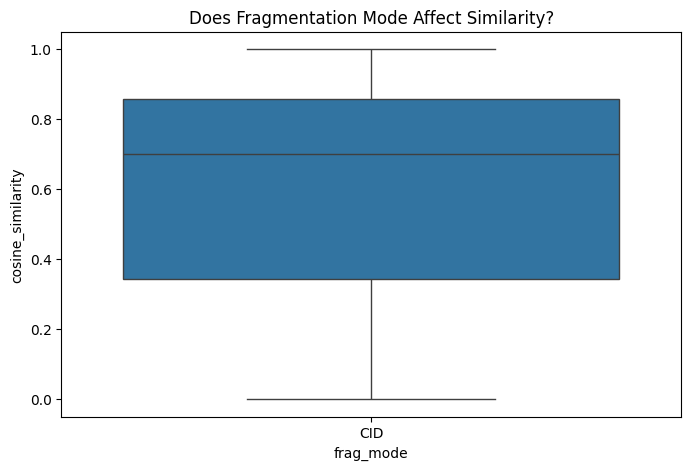

In [102]:
# Plot Similarity vs Frag Mode
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_meta, x='frag_mode', y='cosine_similarity')
plt.title("Does Fragmentation Mode Affect Similarity?")
plt.show()

In [103]:
# 2. CHECK ENERGY CONSISTENCY
print("\n--- Collision Energy Stats ---")
print(f"Rows with valid ACE: {df_meta['ace'].notna().sum()}")
print(f"Rows with valid NCE: {df_meta['nce'].notna().sum()}")


--- Collision Energy Stats ---
Rows with valid ACE: 24807871
Rows with valid NCE: 0


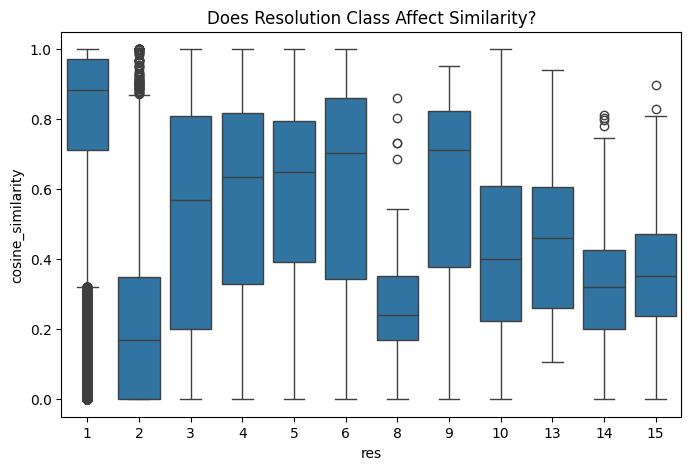

In [104]:
# 3. CHECK RESOLUTION IMPACT
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_meta, x='res', y='cosine_similarity')
plt.title("Does Resolution Class Affect Similarity?")
plt.show()

## Update Collision Energy ACE -> NCE

In [52]:
# ==========================================
# 1. SETUP PATHS
# ==========================================
# Input path (Original file)
input_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl'

# Output path (New updated file)
# We save to a new file first to be safe. You can rename it later.
output_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim_updated.pkl'

In [53]:
# ==========================================
# 2. HELPER FUNCTION: EXTRACT CHARGE
# ==========================================
def get_charge(adduct_str):
    """
    Parses charge state from adduct string (e.g., '[M+2H]2+' -> 2).
    Defaults to 1 if unknown.
    """
    if pd.isna(adduct_str):
        return 1.0
    
    s = str(adduct_str).strip()
    
    # Regex to find charge at the end: e.g., ]2+, ]+, ]3-
    # Matches the number before the +/- sign at the end of the string
    match = re.search(r'\](\d*)[+-]$', s)
    
    if match:
        num = match.group(1)
        if num == '':
            return 1.0 # Case like [M+H]+ or [M-H]-
        else:
            return float(num) # Case like [M+2H]2+
            
    # Fallback: if no brackets, assume 1 (common for simple strings like 'M+H')
    return 1.0

In [54]:
# ==========================================
# 3. LOAD DATA
# ==========================================
print(f"Loading spectral data from: {input_path}")
df = pd.read_pickle(input_path)
print(f"Original Row Count: {len(df)}")

Loading spectral data from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl
Original Row Count: 260706


In [55]:
# Check current NCE status
missing_nce_before = df['nce'].isna().sum()
valid_ace = df['ace'].notna().sum()
print(f"Rows with missing NCE: {missing_nce_before}")
print(f"Rows with valid ACE (source for calc): {valid_ace}")

Rows with missing NCE: 260706
Rows with valid ACE (source for calc): 145633


In [56]:
# ==========================================
# 4. CALCULATE NCE
# ==========================================
print("\nCalculating NCE from Physics Formula...")

# Step A: Extract Charge (Vectorized is harder with regex, applying lambda is safer/clearer)
# This might take a few seconds
df['temp_charge'] = df['prec_type'].apply(get_charge)


Calculating NCE from Physics Formula...


In [57]:
# Step B: Apply Formula
# NCE = (ACE * 500) / (m/z * z)
# We only calculate where ACE is valid. 
# If m/z is 0 or NaN, we avoid division by zero.

def calculate_nce_row(row):
    # If NCE is already there, keep it
    if pd.notna(row['nce']):
        return row['nce']
    
    # If ACE is missing, we can't calculate NCE
    if pd.isna(row['ace']):
        return np.nan
        
    ace = float(row['ace'])
    mz = float(row['prec_mz'])
    z = float(row['temp_charge'])
    
    if mz <= 0 or z <= 0:
        return np.nan
        
    # THE FORMULA
    calculated_nce = (ace * 500.0) / (mz * z)
    return calculated_nce

In [58]:
# Apply calculation
# (Using a mask for speed is better than .apply on whole DF if dataset is huge, 
# but .apply is safer for logic handling)
df['nce_updated'] = df.apply(calculate_nce_row, axis=1)

# Step C: Fill the original 'nce' column
df['nce'] = df['nce_updated']

In [59]:
# ==========================================
# 5. VERIFY & SAVE
# ==========================================
missing_nce_after = df['nce'].isna().sum()
filled_count = missing_nce_before - missing_nce_after

print(f"\n--- Update Complete ---")
print(f"Rows filled with calculated NCE: {filled_count}")
print(f"Remaining missing NCE: {missing_nce_after} (Rows with no ACE available)")


--- Update Complete ---
Rows filled with calculated NCE: 145633
Remaining missing NCE: 115073 (Rows with no ACE available)


In [60]:
# ==========================================
# 6. HANDLE REMAINING MISSING VALUES (IMPUTATION)
# ==========================================
print("\n--- Imputing Missing Values ---")

# Calculate the average NCE from the rows that HAVE data
# (Pandas .mean() automatically ignores NaNs)
global_mean_nce = df['nce'].mean()

print(f"Global Mean NCE calculated from valid data: {global_mean_nce:.4f}")

# Count how many still need filling
remaining_nans = df['nce'].isna().sum()
print(f"Filling {remaining_nans} rows with the global mean...")

# Fill the NaNs
df['nce'] = df['nce'].fillna(global_mean_nce)

# ==========================================
# 7. FINAL SAVE
# ==========================================
# Verify zero NaNs remain
assert df['nce'].isna().sum() == 0, "Error: NaNs still exist after imputation!"

print(f"\nSaving fully cleaned data to: {output_path}")
df.to_pickle(output_path)
print("Success. The spec file is now complete and ready for the model.")


--- Imputing Missing Values ---
Global Mean NCE calculated from valid data: 62.8470
Filling 115073 rows with the global mean...

Saving fully cleaned data to: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim_updated.pkl
Success. The spec file is now complete and ready for the model.


In [61]:
df_updated = pd.read_pickle('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim_updated.pkl')

In [64]:
df_updated.head()

,spec_id,mol_id,prec_type,inst_type,frag_mode,ion_mode,dset,res,ace,nce,prec_mz,peaks,ri,temp_charge,nce_updated
0,MassSpecGymID0036521,22550,[M+H]+,QTOF,CID,P,custom_dataset,4,20.0,31.933772,313.148100,"[(213.0501, 0.01461951), (230.0755, 0.02100750...",NaN,1.0,31.933772
1,MassSpecGymID0196017,9073,[M+H]+,Other,CID,P,custom_dataset,6,NaN,62.847015,706.401000,"[(75.044678, 0.00057482), (75.062744, 0.000790...",NaN,1.0,NaN
2,MassSpecGymID0236624,6981,[M+H]+,FT,CID,P,custom_dataset,6,60.0,47.983670,625.212700,"[(135.044479, 0.1624), (145.028961, 0.16978000...",NaN,1.0,47.983670
3,MassSpecGymID0081645,83,[M+H]+,QTOF,CID,P,custom_dataset,6,20.0,44.818334,223.122975,"[(77.038577, 0.12112112112112113), (94.065126,...",NaN,1.0,44.818334
4,MassSpecGymID0218985,5,[M+H]+,FT,CID,P,custom_dataset,6,20.0,37.300517,268.092800,"[(62.018265, 0.00619), (95.023788, 0.002250000...",NaN,1.0,37.300517


## Exploratory Data Analysis on Resolution of the instrument

In [78]:
# ==========================================
# 1. SETUP PATHS
# ==========================================
# Use your updated spec file if you have it, otherwise the original
spec_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl'
pairs_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_spec_sim_dataset_train.feather'

In [79]:
# ==========================================
# 2. LOAD & MERGE DATA
# ==========================================
print("Loading data...")
df_spec = pd.read_pickle(spec_path)
df_pairs = pd.read_feather(pairs_path)

Loading data...


In [80]:
df_spec.head()

,spec_id,mol_id,prec_type,inst_type,frag_mode,ion_mode,dset,res,ace,nce,prec_mz,peaks,ri,temp_charge,nce_updated
0,MassSpecGymID0036521,22550,[M+H]+,QTOF,CID,P,custom_dataset,4,20.0,31.933772,313.148100,"[(213.0501, 0.01461951), (230.0755, 0.02100750...",NaN,1.0,31.933772
1,MassSpecGymID0196017,9073,[M+H]+,Other,CID,P,custom_dataset,6,NaN,62.847015,706.401000,"[(75.044678, 0.00057482), (75.062744, 0.000790...",NaN,1.0,NaN
2,MassSpecGymID0236624,6981,[M+H]+,FT,CID,P,custom_dataset,6,60.0,47.983670,625.212700,"[(135.044479, 0.1624), (145.028961, 0.16978000...",NaN,1.0,47.983670
3,MassSpecGymID0081645,83,[M+H]+,QTOF,CID,P,custom_dataset,6,20.0,44.818334,223.122975,"[(77.038577, 0.12112112112112113), (94.065126,...",NaN,1.0,44.818334
4,MassSpecGymID0218985,5,[M+H]+,FT,CID,P,custom_dataset,6,20.0,37.300517,268.092800,"[(62.018265, 0.00619), (95.023788, 0.002250000...",NaN,1.0,37.300517


In [81]:
# Create a lookup for Resolution
# We need 'res' for both the "Main" (A) and "Sub" (B) molecules
res_lookup = df_spec.set_index('spec_id')['res'].to_dict()

In [82]:
print("Mapping resolution to pairs...")
df_pairs['res_A'] = df_pairs['name_main'].map(res_lookup)
df_pairs['res_B'] = df_pairs['name_sub'].map(res_lookup)

Mapping resolution to pairs...


In [83]:
# Filter for valid data (Similarity must exist)
# Use 'cosine_similarity' if available, else 'label'
target_col = 'cosine_similarity'
df_clean = df_pairs.dropna(subset=['res_A', 'res_B', target_col]).copy()

print(f"Analyzing {len(df_clean)} pairs with valid resolution data.")

Analyzing 131070016 pairs with valid resolution data.


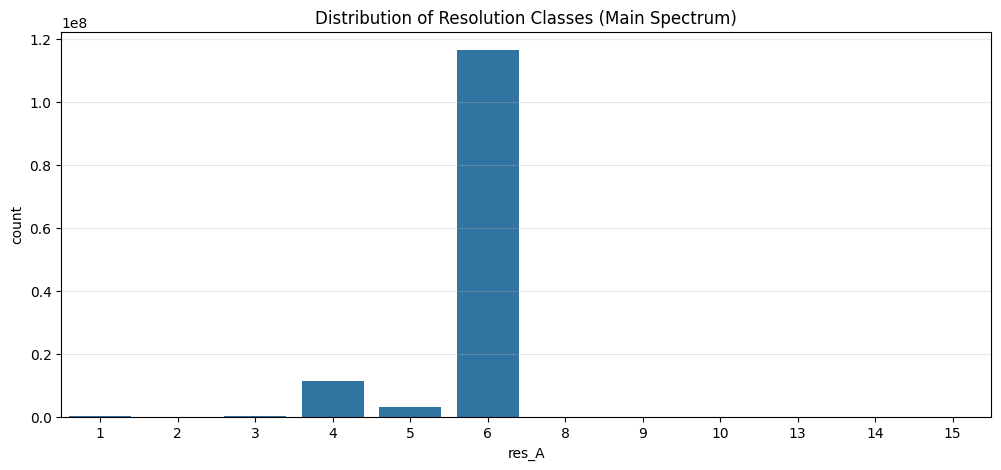

/tmp/ipykernel_3888359/3910536474.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='res_A', y=target_col, palette='viridis', order=sorted(df_clean['res_A'].unique()))


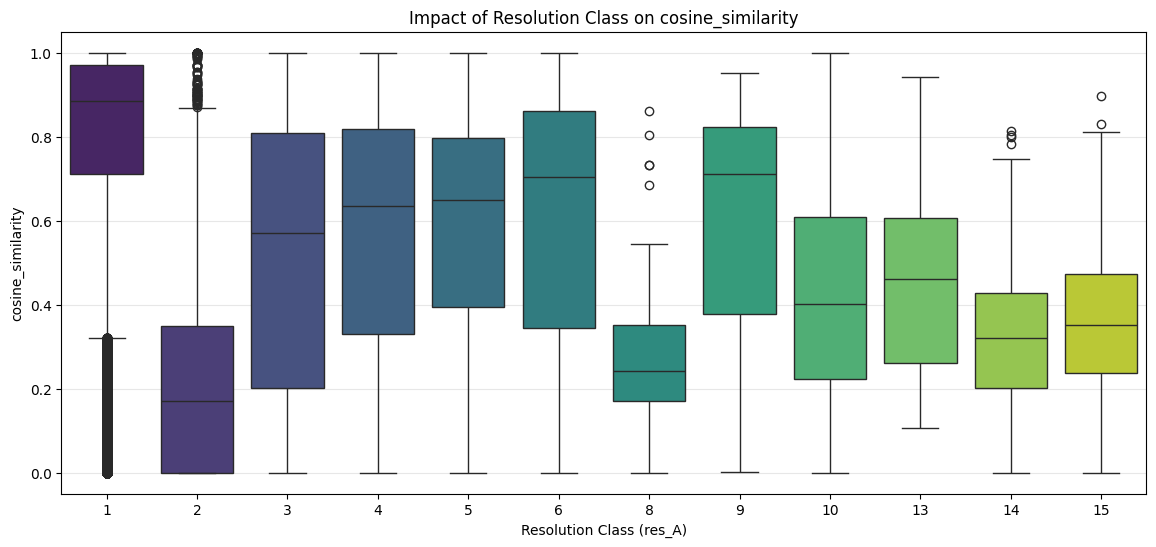


--- Average Similarity by Resolution Class ---
res_A
2     0.233074
8     0.273093
14    0.321372
15    0.362317
10    0.425136
13    0.463372
3     0.510321
4     0.574171
5     0.589553
9     0.589934
6     0.601212
1     0.784104
Name: cosine_similarity, dtype: float64


In [85]:
# ==========================================
# 3. ANALYSIS 1: THE "BAD CLASS" CHECK
# ==========================================
# Do certain resolution classes consistently perform poorly?

# Count plot
plt.figure(figsize=(12, 5))
sns.countplot(data=df_clean, x='res_A', order=sorted(df_clean['res_A'].unique()))
plt.title("Distribution of Resolution Classes (Main Spectrum)")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Box Plot: Similarity vs Resolution Class
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean, x='res_A', y=target_col, palette='viridis', order=sorted(df_clean['res_A'].unique()))
plt.title(f"Impact of Resolution Class on {target_col}")
plt.xlabel("Resolution Class (res_A)")
plt.ylabel(target_col)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Print Stats for the "Bad" classes identified previously
print("\n--- Average Similarity by Resolution Class ---")
print(df_clean.groupby('res_A')[target_col].mean().sort_values())

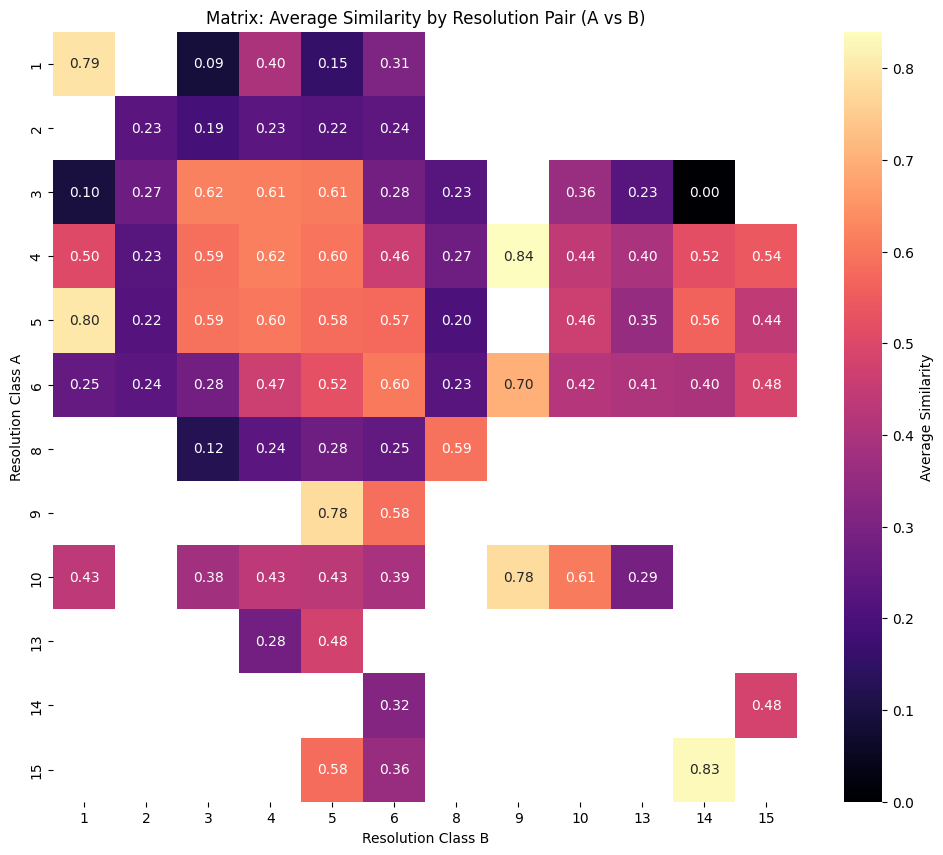

In [86]:
# ==========================================
# 4. ANALYSIS 2: THE "MISMATCH" CHECK
# ==========================================
# Does mixing resolutions (e.g. Res 4 vs Res 2) cause low similarity?

# Create a heatmap matrix
# Rows = Res A, Cols = Res B, Value = Average Similarity
pivot_table = df_clean.pivot_table(index='res_A', columns='res_B', values=target_col, aggfunc='mean')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="magma", cbar_kws={'label': 'Average Similarity'})
plt.title("Matrix: Average Similarity by Resolution Pair (A vs B)")
plt.xlabel("Resolution Class B")
plt.ylabel("Resolution Class A")
plt.show()

In [87]:
# ==========================================
# 5. ANALYSIS 3: INSTRUMENT CORRELATION
# ==========================================
# Let's see what these classes actually mean. Map them to instruments.
# We join back to df_spec to get inst_type
print("\n--- inferred Instrument mapping ---")
df_spec_clean = df_spec.dropna(subset=['res', 'inst_type'])
mapping = df_spec_clean.groupby('res')['inst_type'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
print(mapping)


--- inferred Instrument mapping ---
res
1     Other
2     Other
3        FT
4        FT
5      QTOF
6        FT
7     Other
8        FT
9     Other
10       FT
13    Other
14    Other
15    Other
Name: inst_type, dtype: object


## Proof: Resolution mismatch degrades similarity values

In [2]:
# ==========================================
# 1. SETUP
# ==========================================
# Update paths!
spec_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl'
pairs_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather'
mol_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl'

In [3]:
# Point to your PRETRAINED encoder (The one that knows chemistry)
checkpoint_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/best_finetuned_encoder.pkl'
template_config_path = '/data/nas-gpu/wang/tmach007/massformer/config/template.yml'
config_path = '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml'

In [4]:
# --- Path Setup (Same as your provided code) ---
cwd = Path.cwd()
# Adjust these paths to point to your actual massformer/src directory
parent_directory = os.path.dirname(cwd.parent) 
script_dir = os.path.join(parent_directory, 'massformer', 'src', 'massformer')
sys.path.insert(0, script_dir)
sys.path.insert(0, os.path.join(parent_directory, 'SpectralSimilarityPredictor', 'model'))
# Import MassFormer utils
from gf_data_utils import gf_preprocess, collator
from classifier_siamesemodel_new import MassFormerEncoder

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:207: FutureWarning: `to

In [5]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [6]:
def load_pretrained_encoder(template_config_path, config_path, checkpoint_path, device='cuda'):
    """
    Loads just the MassFormerEncoder from a config and checkpoint.
    """
    print(f"Loading config from {config_path}...")
    with open(config_path, 'r') as f:
        custom_config = yaml.safe_load(f)

    print(f"Loading template_config from {template_config_path}")
    with open(template_config_path, 'r') as f:
        template_config = yaml.safe_load(f)

    full_config = merge_configs(template_config, custom_config)

    # Initialize the encoder using the dictionary from your config
    # usually under config['model']
    model = MassFormerEncoder(
        model_config=full_config.get('model', {}),
        checkpoint_path=checkpoint_path
    )
    encoder = model.encoder
    
    encoder.to(device)
    encoder.eval()
    return encoder

def get_molecule_embedding(smiles_or_mol, encoder, device='cuda'):
    """
    Generates the embedding for a single molecule.
    """
    # 1. Convert to RDKit Mol if string
    if isinstance(smiles_or_mol, str):
        mol = Chem.MolFromSmiles(smiles_or_mol)
    else:
        mol = smiles_or_mol
        
    if mol is None:
        raise ValueError("Invalid SMILES or Molecule provided.")

    # 2. Preprocess (Graph Conversion)
    # gf_preprocess takes (mol, label). Label is arbitrary (0) for inference.
    graph_data = gf_preprocess(mol, 0)
    
    if graph_data is None:
        raise ValueError("Graph preprocessing failed.")

    # 3. Collate (Batching)
    # The collator expects a LIST of graphs, even for a single input
    batched_graph = collator([graph_data])
    
    for key in batched_graph:
        if hasattr(batched_graph[key], 'to'):
            batched_graph[key] = batched_graph[key].to(device)

    # 4. Format Input for Encoder
    # MassFormerEncoder expects a dict with key 'gf_v2_data'
    input_dict = {'gf_v2_data': batched_graph}

    # 5. Forward Pass
    with torch.no_grad():
        embedding = encoder(input_dict)
        
    # Return as numpy array (squeeze to remove batch dim if size is 1)
    return embedding.cpu().squeeze(0)

In [7]:
# ==========================================
# 2. LOAD MODEL (ENCODER ONLY)
# ==========================================
print("Loading Pretrained Encoder...")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Loading Pretrained Encoder...


In [8]:
# 1. Load Model
encoder = load_pretrained_encoder(template_config_path, config_path, checkpoint_path, device)

# 2. Define Molecule
smiles = "CC(=O)OC1=CC=CC=C1C(=O)O" # Aspirin

# 3. Get Embedding
embedding = get_molecule_embedding(smiles, encoder, device)

print(f"Embedding Shape: {embedding.shape}")
print(f"Embedding Vector (First 10): {embedding[:10]}")

Loading config from /data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml...
Loading template_config from /data/nas-gpu/wang/tmach007/massformer/config/template.yml
Loading encoder weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/best_finetuned_encoder.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Embedding Shape: torch.Size([768])
Embedding Vector (First 10): tensor([-0.8918,  0.8619,  0.7112,  1.5370,  0.7644,  1.3218, -0.1486, -0.5383,
         0.2743,  1.3198])


In [9]:
# ==========================================
# 1. SETUP PATHS & IMPORTS
# ==========================================
# Update these paths to your real locations
spec_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl'
pairs_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather'
mol_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl'

# Model Paths
checkpoint_path = '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/best_finetuned_encoder.pkl'
template_config_path = '/data/nas-gpu/wang/tmach007/massformer/config/template.yml'
config_path = '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml'

In [10]:
# Sys Path Setup
cwd = Path.cwd()
parent_directory = os.path.dirname(cwd.parent) 
script_dir = os.path.join(parent_directory, 'massformer', 'src', 'massformer')
sys.path.insert(0, script_dir)
sys.path.insert(0, os.path.join(parent_directory, 'SpectralSimilarityPredictor', 'model'))

from gf_data_utils import gf_preprocess, collator
from classifier_siamesemodel_new import MassFormerEncoder

In [11]:
# ==========================================
# 2. HELPER FUNCTIONS (The Fixed Versions)
# ==========================================
def merge_configs(base_config, custom_config):
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [12]:
def load_pretrained_encoder(template_config_path, config_path, checkpoint_path, device='cuda'):
    print(f"Loading config from {config_path}...")
    with open(config_path, 'r') as f: custom_config = yaml.safe_load(f)
    with open(template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    
    full_config = merge_configs(template_config, custom_config)
    
    print(f"Loading weights from {checkpoint_path}...")
    model = MassFormerEncoder(full_config.get('model', {}), checkpoint_path)
    encoder = model.encoder
    encoder.to(device)
    encoder.eval()
    return encoder

def get_molecule_embedding(smiles_or_mol, encoder, device='cuda', max_nodes=128):
    if isinstance(smiles_or_mol, str):
        mol = Chem.MolFromSmiles(smiles_or_mol)
    else:
        mol = smiles_or_mol
        
    if mol is None: return None # Handle bad mols gracefully

    graph_data = gf_preprocess(mol, 0)
    if graph_data is None: return None
    
    # Graph Size Check
    num_nodes = graph_data.x.size(0)
    if num_nodes == 0 or num_nodes > max_nodes: return None

    # Collate
    batched_graph = collator([graph_data])
    for key in batched_graph:
        if hasattr(batched_graph[key], 'to'):
            batched_graph[key] = batched_graph[key].to(device)

    # Forward
    input_dict = {'gf_v2_data': batched_graph}
    with torch.no_grad():
        embedding = encoder(input_dict)
        
    return embedding.cpu().squeeze(0)

Loading Metadata...
Loading config from /data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml...
Loading weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/best_finetuned_encoder.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Loading encoder weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/best_finetuned_encoder.pkl...
Processing 4858 pairs...


100%|██████████| 4858/4858 [00:07<00:00, 677.89it/s] 


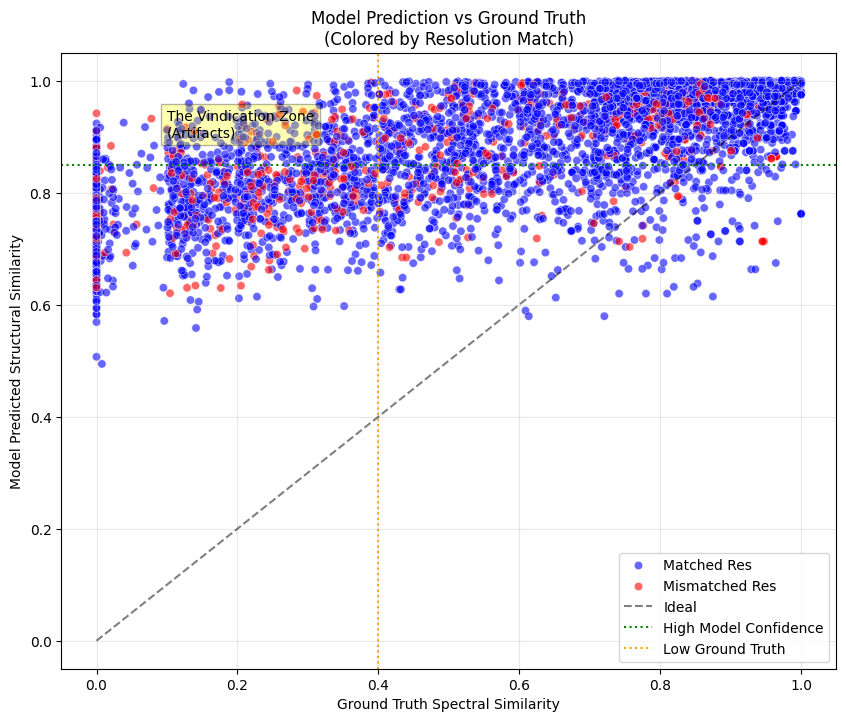


--- RESULTS ---
Total Disagreements (Model High / Truth Low): 387
Caused by Resolution Mismatch: 62
Percentage Explained by Artifact: 16.0%


In [13]:
# ==========================================
# 3. MAIN ANALYSIS SCRIPT
# ==========================================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# A. Load Data
print("Loading Metadata...")
df_spec = pd.read_pickle(spec_path)
df_pairs = pd.read_feather(pairs_path)
df_mol = pd.read_pickle(mol_path)

# Lookups
res_lookup = df_spec.set_index('spec_id')['res'].to_dict()
spec_to_mol = df_spec.set_index('spec_id')['mol_id'].to_dict()
mol_lookup = df_mol.set_index('mol_id')['mol'].to_dict()

# B. Load Model
encoder = load_pretrained_encoder(template_config_path, config_path, checkpoint_path, device)

# C. Process a Sample (First 2000 pairs for speed)
# Ideally, verify on pairs where you suspect issues
df_sample = df_pairs.iloc[:].copy()
print(f"Processing {len(df_sample)} pairs...")

model_sims = []
valid_indices = []

# Embedding Cache (Don't re-compute the same molecule twice)
emb_cache = {}

for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    mol_id_A = spec_to_mol.get(row['name_main'])
    mol_id_B = spec_to_mol.get(row['name_sub'])
    
    # Check Cache A
    if mol_id_A not in emb_cache:
        mol_A = mol_lookup.get(mol_id_A)
        if mol_A:
            emb_cache[mol_id_A] = get_molecule_embedding(mol_A, encoder, device)
        else:
            emb_cache[mol_id_A] = None
            
    # Check Cache B
    if mol_id_B not in emb_cache:
        mol_B = mol_lookup.get(mol_id_B)
        if mol_B:
            emb_cache[mol_id_B] = get_molecule_embedding(mol_B, encoder, device)
        else:
            emb_cache[mol_id_B] = None
            
    emb_A = emb_cache[mol_id_A]
    emb_B = emb_cache[mol_id_B]
    
    if emb_A is not None and emb_B is not None:
        # Calculate Cosine Similarity
        sim = torch.nn.functional.cosine_similarity(emb_A.unsqueeze(0), emb_B.unsqueeze(0)).item()
        model_sims.append(sim)
        valid_indices.append(idx)

# Filter DF
df_sample = df_sample.loc[valid_indices].copy()
df_sample['Model_Sim'] = model_sims

# Map Resolution
df_sample['res_A'] = df_sample['name_main'].map(res_lookup)
df_sample['res_B'] = df_sample['name_sub'].map(res_lookup)

# ==========================================
# 4. THE VINDICATION PLOT
# ==========================================
target_col = 'cosine_similarity' if 'cosine_similarity' in df_sample.columns else 'label'

# Define Resolution Status
df_sample['Res_Status'] = np.where(
    df_sample['res_A'] == df_sample['res_B'], 
    'Matched Res', 
    'Mismatched Res'
)

# PLOT: Ground Truth vs Model Prediction
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_sample, 
    x=target_col, 
    y='Model_Sim', 
    hue='Res_Status', 
    alpha=0.6,
    palette={'Matched Res': 'blue', 'Mismatched Res': 'red'}
)

# Draw Reference Lines
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Ideal")
plt.axhline(0.85, color='green', linestyle=':', label="High Model Confidence")
plt.axvline(0.4, color='orange', linestyle=':', label="Low Ground Truth")

# Annotate the "Vindication Zone"
# Top-Left: Model says High, Truth says Low
plt.text(0.1, 0.9, "The Vindication Zone\n(Artifacts)", bbox=dict(facecolor='yellow', alpha=0.3))

plt.title("Model Prediction vs Ground Truth\n(Colored by Resolution Match)")
plt.xlabel("Ground Truth Spectral Similarity")
plt.ylabel("Model Predicted Structural Similarity")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

# ==========================================
# 5. STATS
# ==========================================
# Count pairs in the "Vindication Zone"
vindicated = df_sample[
    (df_sample['Model_Sim'] > 0.85) & 
    (df_sample[target_col] < 0.4)
]

mismatched_count = len(vindicated[vindicated['Res_Status'] == 'Mismatched Res'])
total_vindicated = len(vindicated)

if total_vindicated > 0:
    print(f"\n--- RESULTS ---")
    print(f"Total Disagreements (Model High / Truth Low): {total_vindicated}")
    print(f"Caused by Resolution Mismatch: {mismatched_count}")
    print(f"Percentage Explained by Artifact: {mismatched_count/total_vindicated*100:.1f}%")
else:
    print("No significant disagreements found in this sample.")

## Extract MassSpecGym and Casmi pairs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Define file paths
input_feather_file = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_test.feather"
spec_df_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl"
mol_df_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_spec_sim.pkl"
output_tsv_file = "high_sim_mona_smiles.tsv"

In [3]:
# 2. Load the data
print("Loading dataset and metadata files...")
df = pd.read_feather(input_feather_file)
spec_df = pd.read_pickle(spec_df_path)
mol_df = pd.read_pickle(mol_df_path)

Loading dataset and metadata files...


In [4]:
# 3. Filter for Cross-Dataset Pairs (MoNA and MassSpecGym)
# Condition A: main is MassSpecGym AND sub is MoNA
cond_a = (
    df['name_main'].str.startswith('MassSpecGymID', na=False) & 
    df['name_sub'].str.startswith('MoNA_', na=False)
)

# Condition B: main is MoNA AND sub is MassSpecGym
cond_b = (
    df['name_main'].str.startswith('MoNA_', na=False) & 
    df['name_sub'].str.startswith('MassSpecGymID', na=False)
)

In [5]:
# Apply filter and get cross-dataset pairs
cross_dataset_df = df[cond_a | cond_b].copy()
print(f"Cross-dataset pairs found (MoNA vs MassSpecGym): {len(cross_dataset_df)}")

Cross-dataset pairs found (MoNA vs MassSpecGym): 414


In [6]:
# 4. Filter for high cosine similarity (> 0.7)
high_sim_df = cross_dataset_df[cross_dataset_df['cosine_similarity'] > 0.7].copy()
print(f"Pairs with cosine similarity > 0.7: {len(high_sim_df)}")

Pairs with cosine similarity > 0.7: 82


In [7]:
# 5. Extract the MoNA IDs into a single column
# Since the MoNA ID could be in either 'name_main' or 'name_sub', we extract it conditionally
high_sim_df['mona_id'] = high_sim_df.apply(
    lambda row: row['name_main'] if str(row['name_main']).startswith('MoNA_') else row['name_sub'], 
    axis=1
)

# Also extract the corresponding MassSpecGym ID for reference
high_sim_df['msg_id'] = high_sim_df.apply(
    lambda row: row['name_main'] if str(row['name_main']).startswith('MassSpecGymID') else row['name_sub'], 
    axis=1
)

In [8]:
# 6. Merge with Metadata to get SMILES
# A. Merge with spec_df to get the mol_id for the MoNA spectra
# We assume spec_df's 'spec_id' contains the MoNA IDs.
merged_with_spec = pd.merge(
    high_sim_df, 
    spec_df[['spec_id', 'mol_id']], 
    left_on='mona_id', 
    right_on='spec_id', 
    how='left'
)

# B. Merge with mol_df to get the actual SMILES string using mol_id
final_df = pd.merge(
    merged_with_spec,
    mol_df[['mol_id', 'smiles']],
    on='mol_id',
    how='left'
)

In [9]:
# 7. Clean up and format the output
# Select only the relevant columns for the final output
output_columns = ['mona_id', 'msg_id', 'cosine_similarity', 'smiles']
final_output = final_df[output_columns].copy()

# Rename columns for clarity if desired
final_output.rename(columns={'smiles': 'mona_smiles'}, inplace=True)

In [10]:
# 8. Save to TSV
final_output.to_csv(output_tsv_file, sep='\t', index=False)
print("=" * 50)
print(f"Successfully extracted {len(final_output)} records.")
print(f"Results saved to: {output_tsv_file}")
print("=" * 50)

Successfully extracted 82 records.
Results saved to: high_sim_mona_smiles.tsv


In [11]:
display(final_output.head())

,mona_id,msg_id,cosine_similarity,mona_smiles
0,MoNA_42475,MassSpecGymID0182380,0.852545,COc1cc2oc3c(Cl)c(OC)cc(C)c3c(=O)c2c(O)c1Cl
1,MoNA_67357,MassSpecGymID0190474,0.752482,CC1=CCC2(C)C(=O)C(=O)C(C(C)CO)=C2CCC(C)C(O)CCC...
2,MoNA_8451,MassSpecGymID0009548,0.878949,COc1ccc(C=CC(=O)C=Cc2ccc(OC)cc2)cc1
3,MoNA_67525,MassSpecGymID0193644,0.837745,COC(=O)CC(O)C1OC(c2ccccc2)C(O)C1O
4,MoNA_67252,MassSpecGymID0181895,0.753204,C=C1C(=O)OC2CC(C)=C3CC(=O)C(C)C3CC12


In [12]:
# 1. Get the top 5 highest similarity pairs
# Sort descending by cosine similarity and take the first 5 rows
top_5_pairs = final_output.sort_values(by='cosine_similarity', ascending=False).head(5)

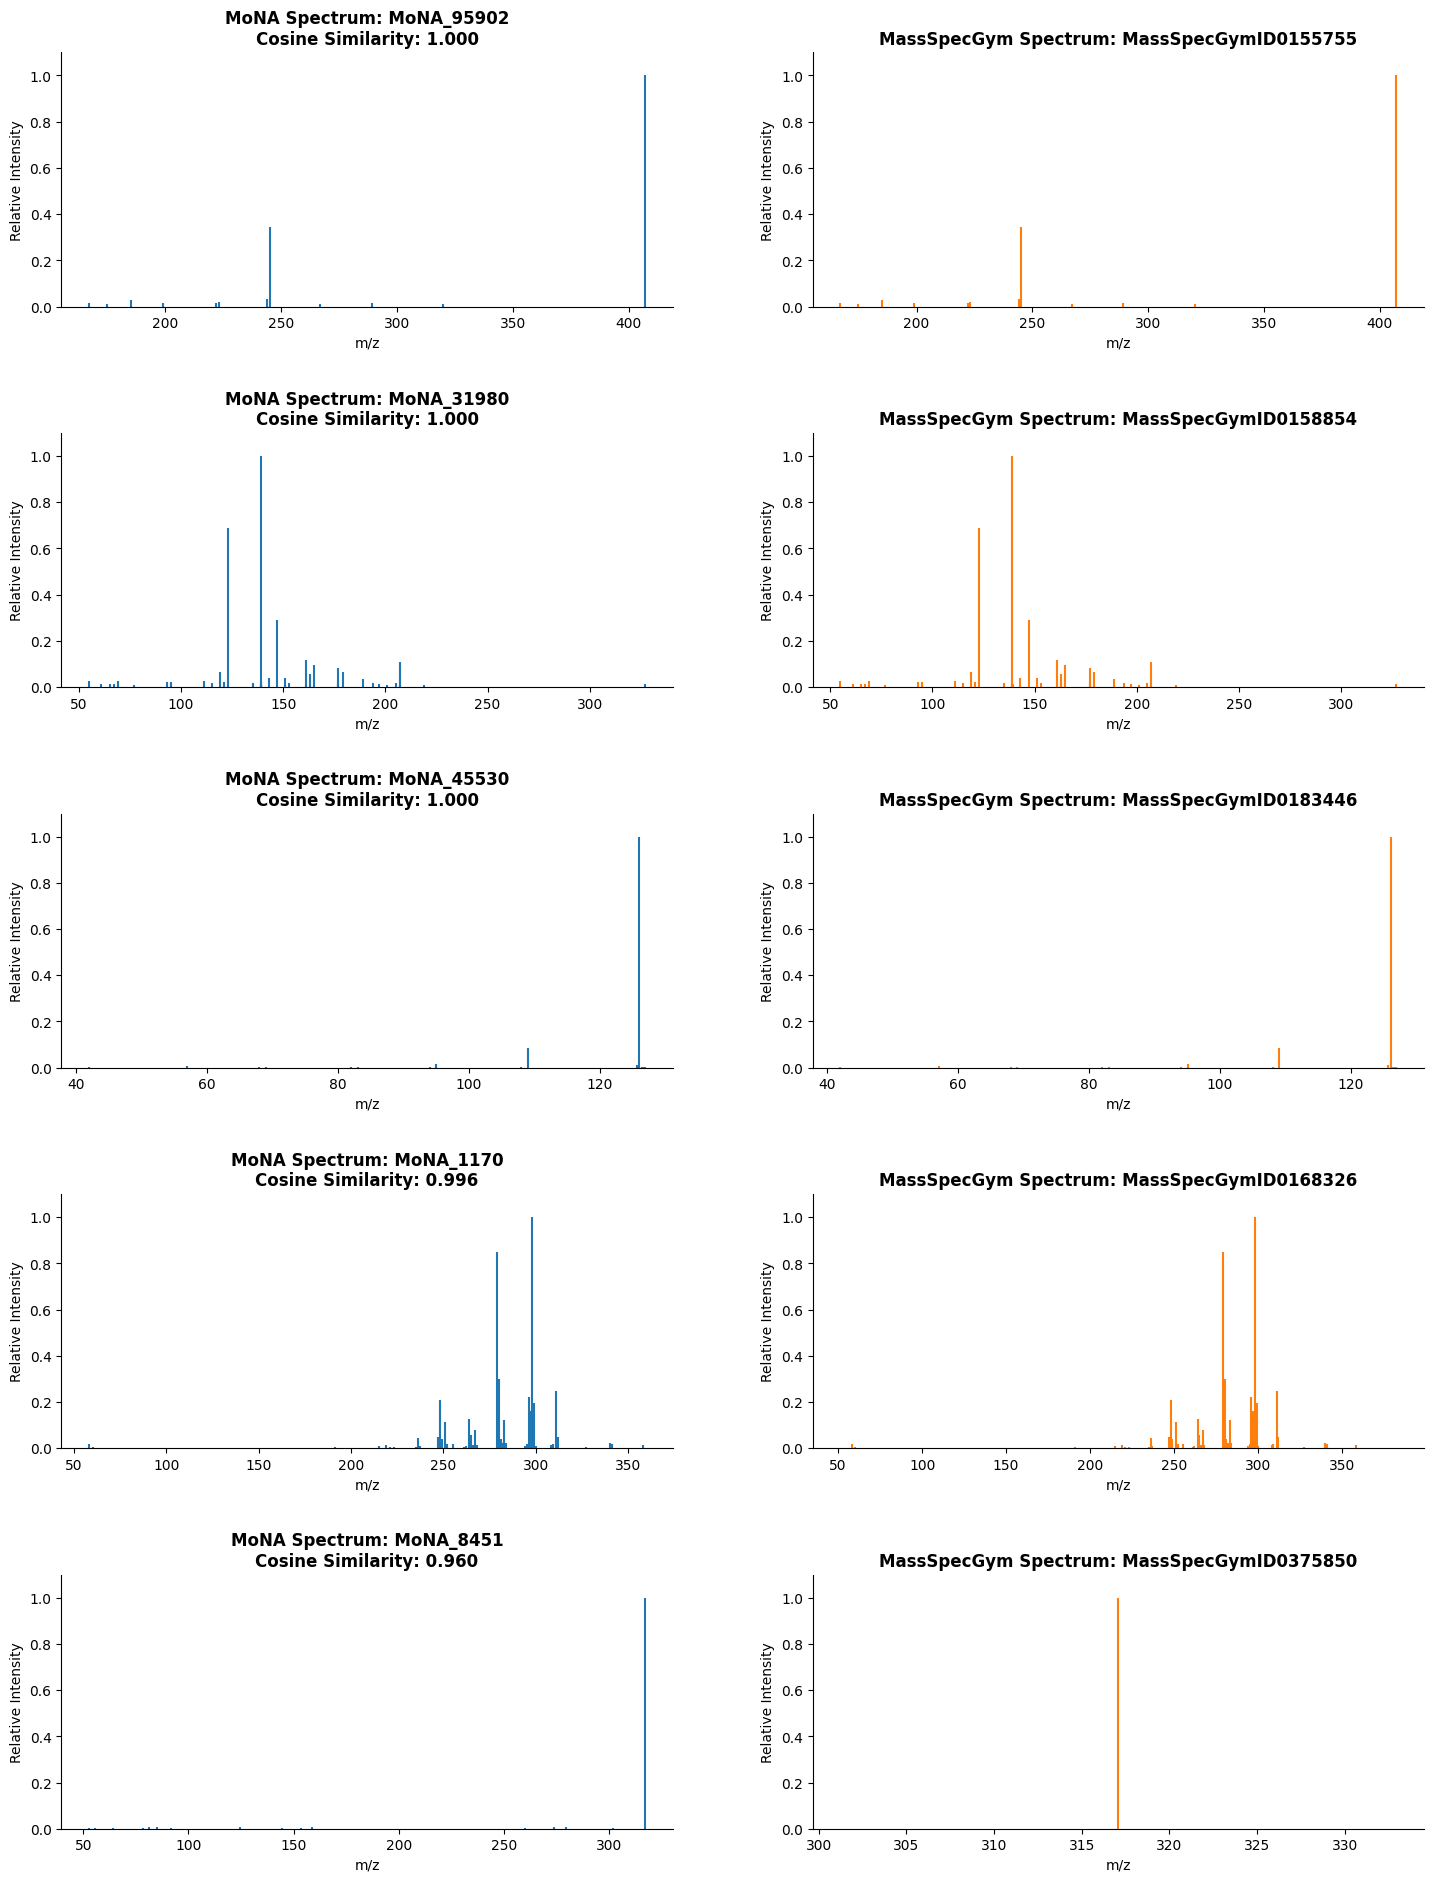

In [13]:
# 2. Setup the Matplotlib figure
# We want 5 rows (one for each pair) and 2 columns (MoNA left, MassSpecGym right)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
fig.tight_layout(pad=7.0) # Adds padding so titles and axis labels don't overlap

# 3. Loop through the top 5 pairs and plot
for i, (_, row) in enumerate(top_5_pairs.iterrows()):
    mona_id = row['mona_id']
    msg_id = row['msg_id']
    sim_score = row['cosine_similarity']
    
    # --- Extract Peaks ---
    # .loc finds the row in spec_df matching the ID, and .values[0] extracts the list of peak tuples
    mona_peaks = spec_df.loc[spec_df['spec_id'] == mona_id, 'peaks'].values[0]
    msg_peaks = spec_df.loc[spec_df['spec_id'] == msg_id, 'peaks'].values[0]
    
    # Unpack the list of tuples [(mz1, int1), (mz2, int2)] into separate x and y lists
    mona_mz = [p[0] for p in mona_peaks] if isinstance(mona_peaks, list) else []
    mona_int = [p[1] for p in mona_peaks] if isinstance(mona_peaks, list) else []
    
    msg_mz = [p[0] for p in msg_peaks] if isinstance(msg_peaks, list) else []
    msg_int = [p[1] for p in msg_peaks] if isinstance(msg_peaks, list) else []

    # --- Plot MoNA Spectrum (Left Column) ---
    ax_mona = axes[i, 0]
    if mona_mz:
        # vlines draws a vertical line from ymin (0) to ymax (the intensity value) at each m/z
        ax_mona.vlines(mona_mz, 0, mona_int, color='tab:blue', linewidth=1.5)
        ax_mona.set_ylim(0, max(mona_int) * 1.1) # Add 10% headroom above the tallest peak
        
    ax_mona.set_title(f"MoNA Spectrum: {mona_id}\nCosine Similarity: {sim_score:.3f}", fontweight='bold')
    ax_mona.set_xlabel("m/z")
    ax_mona.set_ylabel("Relative Intensity")
    ax_mona.spines['top'].set_visible(False)
    ax_mona.spines['right'].set_visible(False)
    
    # --- Plot MassSpecGym Spectrum (Right Column) ---
    ax_msg = axes[i, 1]
    if msg_mz:
        ax_msg.vlines(msg_mz, 0, msg_int, color='tab:orange', linewidth=1.5)
        ax_msg.set_ylim(0, max(msg_int) * 1.1)
        
    ax_msg.set_title(f"MassSpecGym Spectrum: {msg_id}", fontweight='bold')
    ax_msg.set_xlabel("m/z")
    ax_msg.set_ylabel("Relative Intensity")
    ax_msg.spines['top'].set_visible(False)
    ax_msg.spines['right'].set_visible(False)

# Display the final composite plot
plt.show()

### Check if molecules are unique

In [14]:
# 1. Map mol_ids for BOTH spectra
# Get MoNA mol_id
df_filtered = high_sim_df.merge(
    spec_df[['spec_id', 'mol_id']], left_on='mona_id', right_on='spec_id', how='left'
).rename(columns={'mol_id': 'mona_mol_id'}).drop(columns=['spec_id'])

# Get MassSpecGym mol_id
df_filtered = df_filtered.merge(
    spec_df[['spec_id', 'mol_id']], left_on='msg_id', right_on='spec_id', how='left'
).rename(columns={'mol_id': 'msg_mol_id'}).drop(columns=['spec_id'])

In [15]:
# 2. Map InChIKey and SMILES for BOTH spectra
# Get MoNA structure info
df_filtered = df_filtered.merge(
    mol_df[['mol_id', 'inchikey_s', 'smiles']], left_on='mona_mol_id', right_on='mol_id', how='left'
).rename(columns={'inchikey_s': 'mona_inchikey', 'smiles': 'mona_smiles'}).drop(columns=['mol_id'])

# Get MassSpecGym structure info
df_filtered = df_filtered.merge(
    mol_df[['mol_id', 'inchikey_s', 'smiles']], left_on='msg_mol_id', right_on='mol_id', how='left'
).rename(columns={'inchikey_s': 'msg_inchikey', 'smiles': 'msg_smiles'}).drop(columns=['mol_id'])

In [16]:
# 3. Filter out pairs that are the exact same molecule
# Keep only rows where the 2D InChIKey skeletons do NOT match
strict_diff_pairs_df = df_filtered[df_filtered['mona_inchikey'] != df_filtered['msg_inchikey']].copy()

print(f"Pairs before identity filter: {len(df_filtered)}")
print(f"Pairs after removing identical molecules: {len(strict_diff_pairs_df)}")

Pairs before identity filter: 82
Pairs after removing identical molecules: 77


In [17]:
# 4. Get the true top 5 structurally distinct, highly similar pairs
top_5_distinct_pairs = strict_diff_pairs_df.sort_values(by='cosine_similarity', ascending=False).head(5)

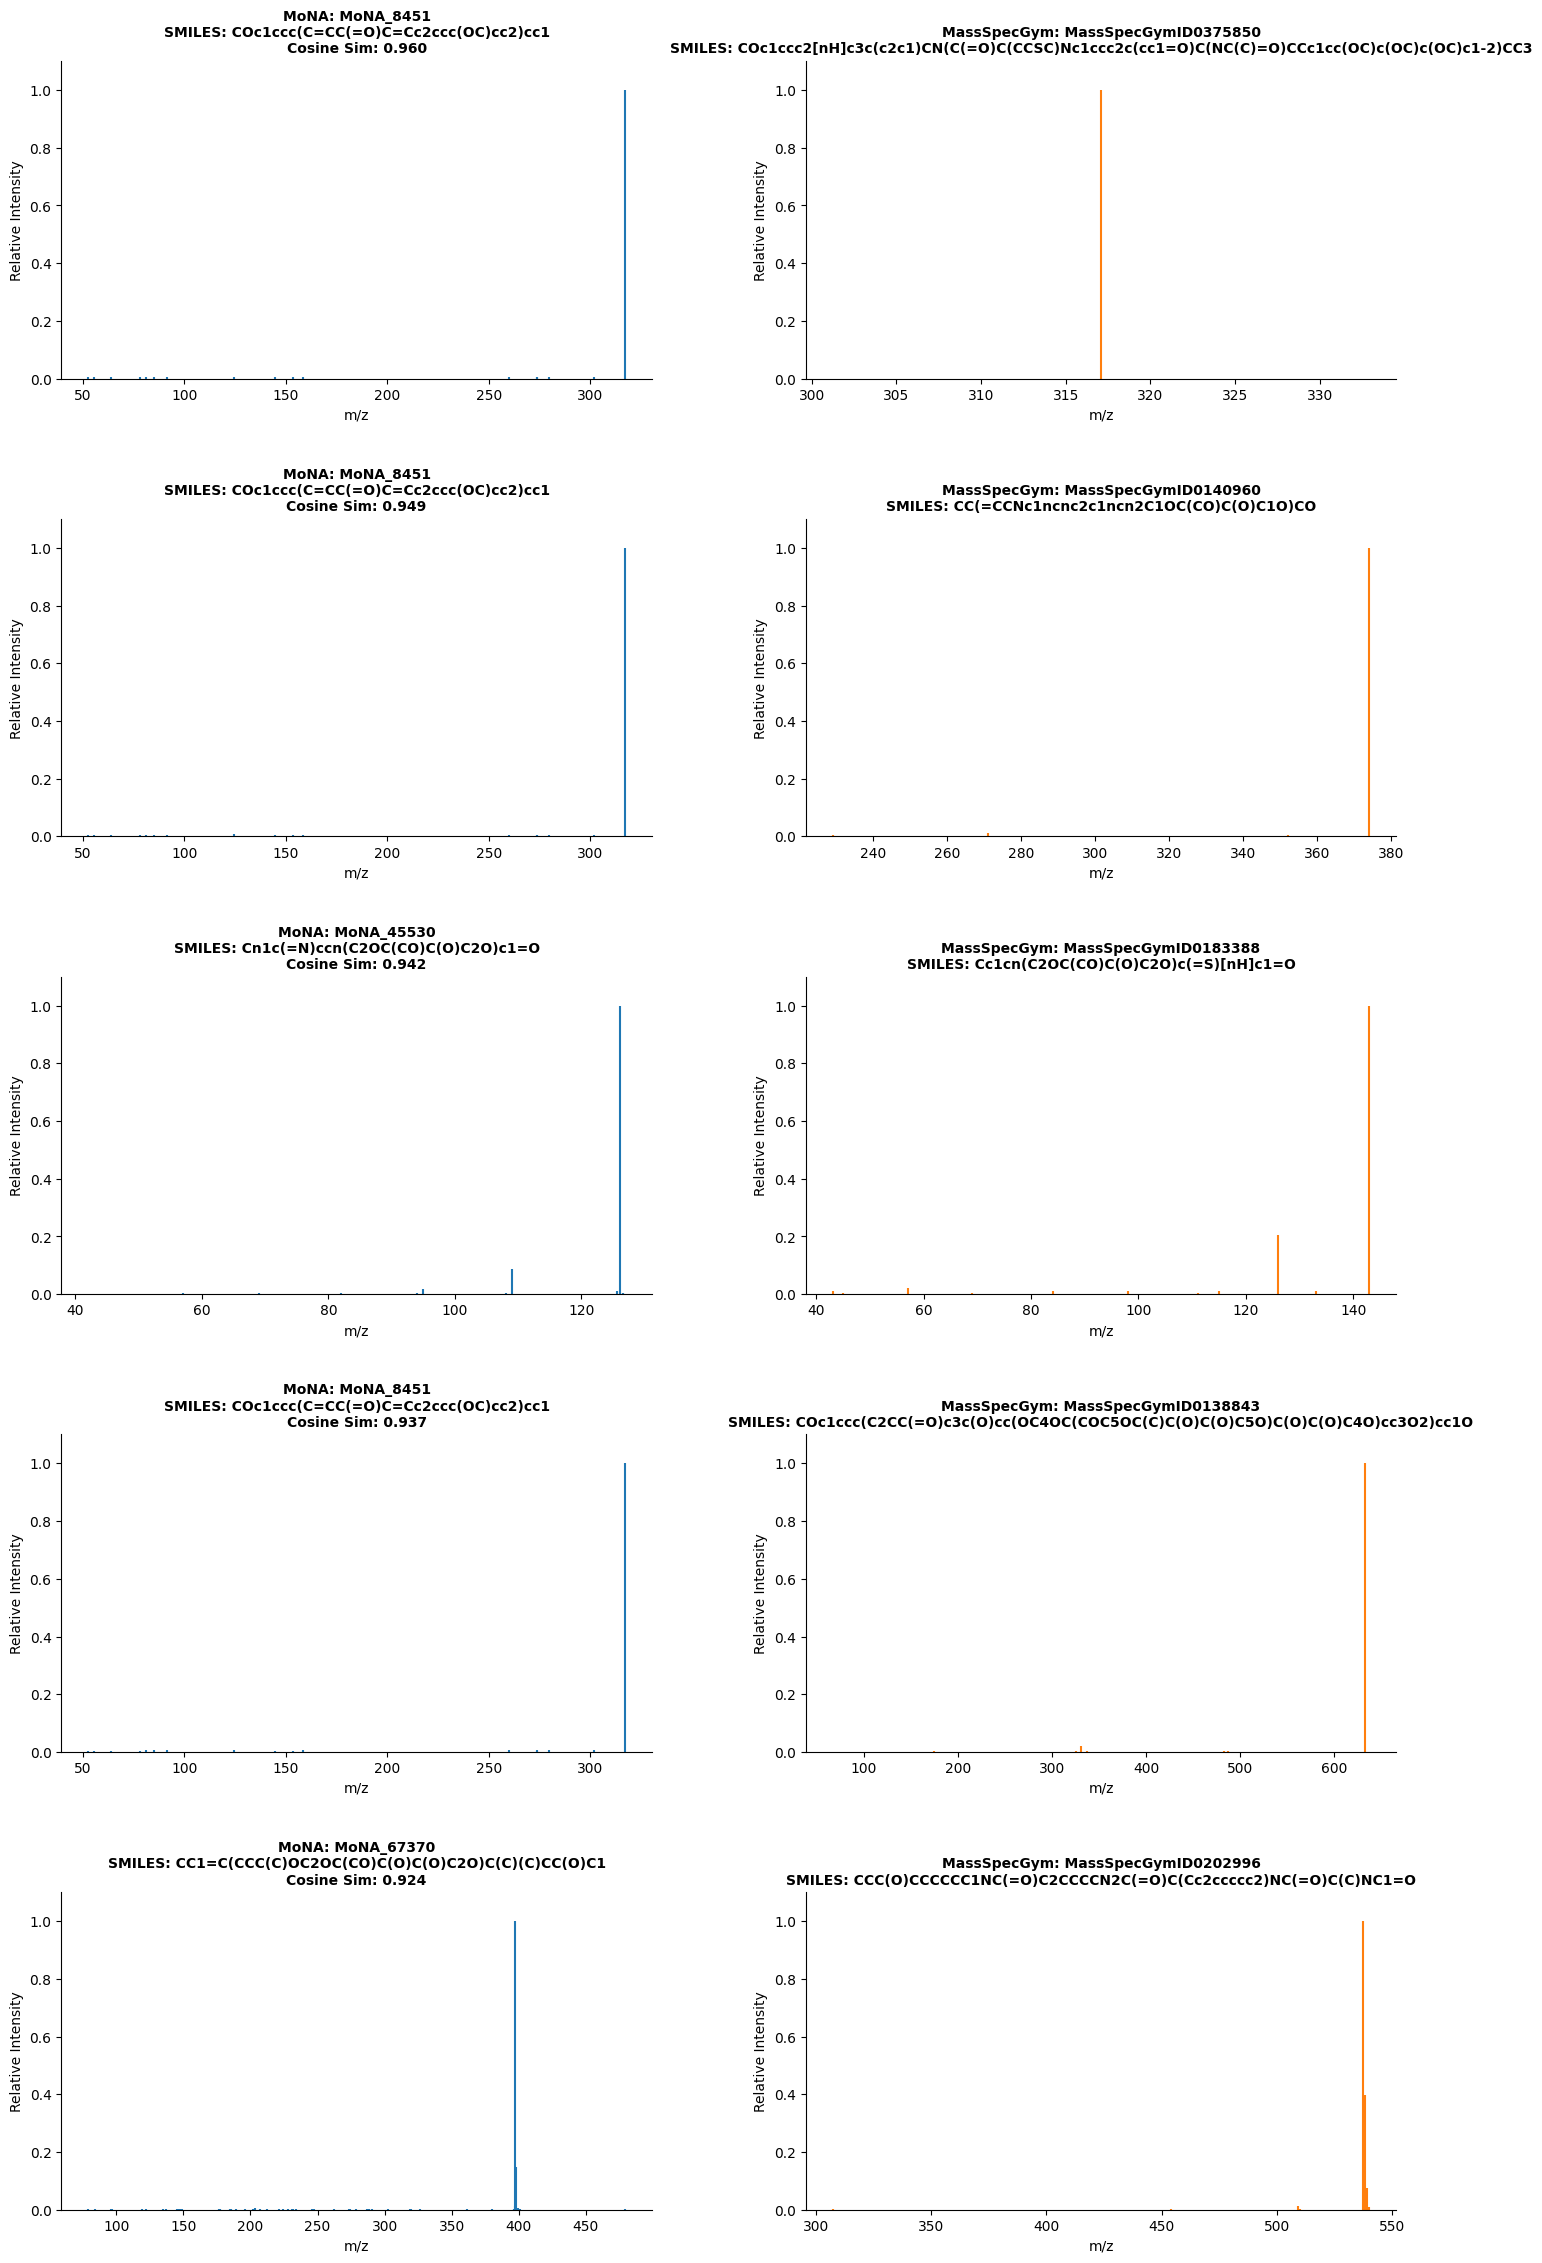

In [18]:
# Setup the Matplotlib figure (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 24))
fig.tight_layout(pad=8.0) # Increased padding for longer SMILES titles

for i, (_, row) in enumerate(top_5_distinct_pairs.iterrows()):
    mona_id = row['mona_id']
    msg_id = row['msg_id']
    sim_score = row['cosine_similarity']
    mona_smiles = row['mona_smiles']
    msg_smiles = row['msg_smiles']
    
    # Extract Peaks
    mona_peaks = spec_df.loc[spec_df['spec_id'] == mona_id, 'peaks'].values[0]
    msg_peaks = spec_df.loc[spec_df['spec_id'] == msg_id, 'peaks'].values[0]
    
    mona_mz = [p[0] for p in mona_peaks] if isinstance(mona_peaks, list) else []
    mona_int = [p[1] for p in mona_peaks] if isinstance(mona_peaks, list) else []
    
    msg_mz = [p[0] for p in msg_peaks] if isinstance(msg_peaks, list) else []
    msg_int = [p[1] for p in msg_peaks] if isinstance(msg_peaks, list) else []

    # Plot MoNA Spectrum (Left)
    ax_mona = axes[i, 0]
    if mona_mz:
        ax_mona.vlines(mona_mz, 0, mona_int, color='tab:blue', linewidth=1.5)
        ax_mona.set_ylim(0, max(mona_int) * 1.1)
        
    ax_mona.set_title(f"MoNA: {mona_id}\nSMILES: {mona_smiles}\nCosine Sim: {sim_score:.3f}", 
                      fontweight='bold', fontsize=10)
    ax_mona.set_xlabel("m/z")
    ax_mona.set_ylabel("Relative Intensity")
    ax_mona.spines['top'].set_visible(False)
    ax_mona.spines['right'].set_visible(False)
    
    # Plot MassSpecGym Spectrum (Right)
    ax_msg = axes[i, 1]
    if msg_mz:
        ax_msg.vlines(msg_mz, 0, msg_int, color='tab:orange', linewidth=1.5)
        ax_msg.set_ylim(0, max(msg_int) * 1.1)
        
    ax_msg.set_title(f"MassSpecGym: {msg_id}\nSMILES: {msg_smiles}", 
                     fontweight='bold', fontsize=10)
    ax_msg.set_xlabel("m/z")
    ax_msg.set_ylabel("Relative Intensity")
    ax_msg.spines['top'].set_visible(False)
    ax_msg.spines['right'].set_visible(False)

plt.show()

### Save the SMILES string for the distinct pairs

In [19]:
# 1. Define the output file name
distinct_output_tsv = "distinct_high_sim_pairs_smiles.tsv"

In [20]:
# 2. Select the relevant columns for the final output
columns_to_save = [
    'mona_id', 
    'msg_id', 
    'cosine_similarity', 
    'mona_smiles', 
    'msg_smiles'
]

In [21]:
# Create a clean dataframe with just these columns
final_distinct_output = strict_diff_pairs_df[columns_to_save].copy()

In [22]:
# 3. Save to TSV
final_distinct_output.to_csv(distinct_output_tsv, sep='\t', index=False)

In [23]:
# 4. Print confirmation
print("=" * 60)
print(f"Successfully saved {len(final_distinct_output)} distinct molecule pairs.")
print(f"File saved to: {distinct_output_tsv}")
print("=" * 60)

# Display the first few rows to verify
display(final_distinct_output.head())

Successfully saved 77 distinct molecule pairs.
File saved to: distinct_high_sim_pairs_smiles.tsv


,mona_id,msg_id,cosine_similarity,mona_smiles,msg_smiles
0,MoNA_42475,MassSpecGymID0182380,0.852545,COc1cc2oc3c(Cl)c(OC)cc(C)c3c(=O)c2c(O)c1Cl,CC1(C)SC2C(N=CN3CCCCCC3)C(=O)N2C1C(=O)O
1,MoNA_67357,MassSpecGymID0190474,0.752482,CC1=CCC2(C)C(=O)C(=O)C(C(C)CO)=C2CCC(C)C(O)CCC...,CC(C)c1ccc2c(c1)C(O)CC1C(C)(CO)CCCC21C
2,MoNA_8451,MassSpecGymID0009548,0.878949,COc1ccc(C=CC(=O)C=Cc2ccc(OC)cc2)cc1,Nc1ncnc2c1ncn2C1CC(O)C(CO)O1
3,MoNA_67525,MassSpecGymID0193644,0.837745,COC(=O)CC(O)C1OC(c2ccccc2)C(O)C1O,CC1=C(C)C(=O)OC(C(C)(O)C2CCC3C4CC=C5CC(OC6OC(C...
4,MoNA_67252,MassSpecGymID0181895,0.753204,C=C1C(=O)OC2CC(C)=C3CC(=O)C(C)C3CC12,COc1ccccc1OCC(O)CN1CCN(CC(=O)Nc2c(C)cccc2C)CC1


### Filter out pairs where the MoNA molecule is present in the Mass Spec Gym

In [24]:
# 1. Identify all InChIKeys that exist anywhere in MassSpecGym
# Filter spec_df for all MassSpecGym entries
msg_all_specs = spec_df[spec_df['spec_id'].str.startswith('MassSpecGymID', na=False)]

# Extract their unique mol_ids
msg_all_mol_ids = msg_all_specs['mol_id'].unique()

# Map these mol_ids to their InChIKeys using mol_df
msg_all_inchikeys = mol_df[mol_df['mol_id'].isin(msg_all_mol_ids)]['inchikey_s'].dropna().unique()

# Convert to a Python set for ultra-fast lookups
msg_inchikey_set = set(msg_all_inchikeys)

print(f"Total unique molecular skeletons (InChIKeys) in MassSpecGym: {len(msg_inchikey_set)}")

# 2. Filter your previously distinct pairs (strict_diff_pairs_df)
# We want to keep rows where the MoNA molecule's InChIKey is NOT IN the MassSpecGym set.
# The tilde (~) operator negates the condition, meaning "is NOT in".
novel_mona_pairs_df = strict_diff_pairs_df[~strict_diff_pairs_df['mona_inchikey'].isin(msg_inchikey_set)].copy()

print("=" * 60)
print(f"Pairs before global leakage filter: {len(strict_diff_pairs_df)}")
print(f"Pairs after ensuring MoNA molecule is completely novel: {len(novel_mona_pairs_df)}")
print("=" * 60)

# 3. (Optional) Save the truly novel pairs to a new TSV
final_columns = ['mona_id', 'msg_id', 'cosine_similarity', 'mona_smiles', 'msg_smiles']
novel_mona_pairs_df[final_columns].to_csv("truly_novel_mona_pairs.tsv", sep='\t', index=False)

# Display the top truly novel pairs
display(novel_mona_pairs_df[final_columns].head())

Total unique molecular skeletons (InChIKeys) in MassSpecGym: 27952
Pairs before global leakage filter: 77
Pairs after ensuring MoNA molecule is completely novel: 17


,mona_id,msg_id,cosine_similarity,mona_smiles,msg_smiles
0,MoNA_42475,MassSpecGymID0182380,0.852545,COc1cc2oc3c(Cl)c(OC)cc(C)c3c(=O)c2c(O)c1Cl,CC1(C)SC2C(N=CN3CCCCCC3)C(=O)N2C1C(=O)O
1,MoNA_67357,MassSpecGymID0190474,0.752482,CC1=CCC2(C)C(=O)C(=O)C(C(C)CO)=C2CCC(C)C(O)CCC...,CC(C)c1ccc2c(c1)C(O)CC1C(C)(CO)CCCC21C
4,MoNA_67252,MassSpecGymID0181895,0.753204,C=C1C(=O)OC2CC(C)=C3CC(=O)C(C)C3CC12,COc1ccccc1OCC(O)CN1CCN(CC(=O)Nc2c(C)cccc2C)CC1
9,MoNA_42471,MassSpecGymID0298116,0.764742,COc1cc2oc3c(Cl)c(OC)c(Cl)c(C)c3c(=O)c2c(O)c1Cl,COc1cc2occc2c2oc(=O)ccc12
15,MoNA_42487,MassSpecGymID0071804,0.856647,Cc1cc(O)c(Cl)c2oc3c(Cl)c(O)c(Cl)c(O)c3c(=O)c12,COC(=O)C1C2CC3c4[nH]c5cc(OC)ccc5c4CCN3CC2CC(OC...


### Save these novel molecule pairs

In [25]:
# 1. Define your output file names
final_tsv_path = "novel_mona_msg_pairs.tsv"
final_feather_path = "novel_mona_msg_pairs.feather"

# 2. Select the final columns to keep
columns_to_keep = [
    'mona_id', 
    'msg_id', 
    'cosine_similarity', 
    'mona_smiles', 
    'msg_smiles'
]

# Create a clean DataFrame for saving
final_save_df = novel_mona_pairs_df[columns_to_keep].copy()

# 3. Save as TSV
final_save_df.to_csv(final_tsv_path, sep='\t', index=False)
print(f"Saved {len(final_save_df)} records to TSV: {final_tsv_path}")

# 4. Save as Feather
# Feather requires a default index, so we reset it just in case filtering messed it up
final_save_df.reset_index(drop=True).to_feather(final_feather_path)
print(f"Saved {len(final_save_df)} records to Feather: {final_feather_path}")

# Display a quick sanity check
display(final_save_df.head())

Saved 17 records to TSV: novel_mona_msg_pairs.tsv
Saved 17 records to Feather: novel_mona_msg_pairs.feather


,mona_id,msg_id,cosine_similarity,mona_smiles,msg_smiles
0,MoNA_42475,MassSpecGymID0182380,0.852545,COc1cc2oc3c(Cl)c(OC)cc(C)c3c(=O)c2c(O)c1Cl,CC1(C)SC2C(N=CN3CCCCCC3)C(=O)N2C1C(=O)O
1,MoNA_67357,MassSpecGymID0190474,0.752482,CC1=CCC2(C)C(=O)C(=O)C(C(C)CO)=C2CCC(C)C(O)CCC...,CC(C)c1ccc2c(c1)C(O)CC1C(C)(CO)CCCC21C
4,MoNA_67252,MassSpecGymID0181895,0.753204,C=C1C(=O)OC2CC(C)=C3CC(=O)C(C)C3CC12,COc1ccccc1OCC(O)CN1CCN(CC(=O)Nc2c(C)cccc2C)CC1
9,MoNA_42471,MassSpecGymID0298116,0.764742,COc1cc2oc3c(Cl)c(OC)c(Cl)c(C)c3c(=O)c2c(O)c1Cl,COc1cc2occc2c2oc(=O)ccc12
15,MoNA_42487,MassSpecGymID0071804,0.856647,Cc1cc(O)c(Cl)c2oc3c(Cl)c(O)c(Cl)c(O)c3c(=O)c12,COC(=O)C1C2CC3c4[nH]c5cc(OC)ccc5c4CCN3CC2CC(OC...
